In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Dict, List, Tuple

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid")

In [16]:
variant = {
        "name":"Вариант 2",
        "ages":[0, 1, 2, 3, 4, 5],
        "revenue":[145, 140, 140, 130, 128, 124],
        "cost":[100, 115, 100, 95, 90, 125],
        "replace":[0, 40, 45, 51, 51, 60]
}


N_YEARS = len(variant['ages'])-1

variant


{'name': 'Вариант 2',
 'ages': [0, 1, 2, 3, 4, 5],
 'revenue': [145, 140, 140, 130, 128, 124],
 'cost': [100, 115, 100, 95, 90, 125],
 'replace': [0, 40, 45, 51, 51, 60]}

In [17]:
df = pd.DataFrame({
    "Возраст t": variant["ages"],
    "Доход r(t)": variant['revenue'],
    "Затраты c(t)": variant['cost'],
    "Чистая прибыль g(t)=r(t)-c(t)": np.array(variant['revenue']) - np.array(variant['cost']),
    "Затраты на замену p(t)": variant['replace'],
})

df

,Возраст t,Доход r(t),Затраты c(t),Чистая прибыль g(t)=r(t)-c(t),Затраты на замену p(t)
0,0,145,100,45,0
1,1,140,115,25,40
2,2,140,100,40,45
3,3,130,95,35,51
4,4,128,90,38,51
5,5,124,125,-1,60


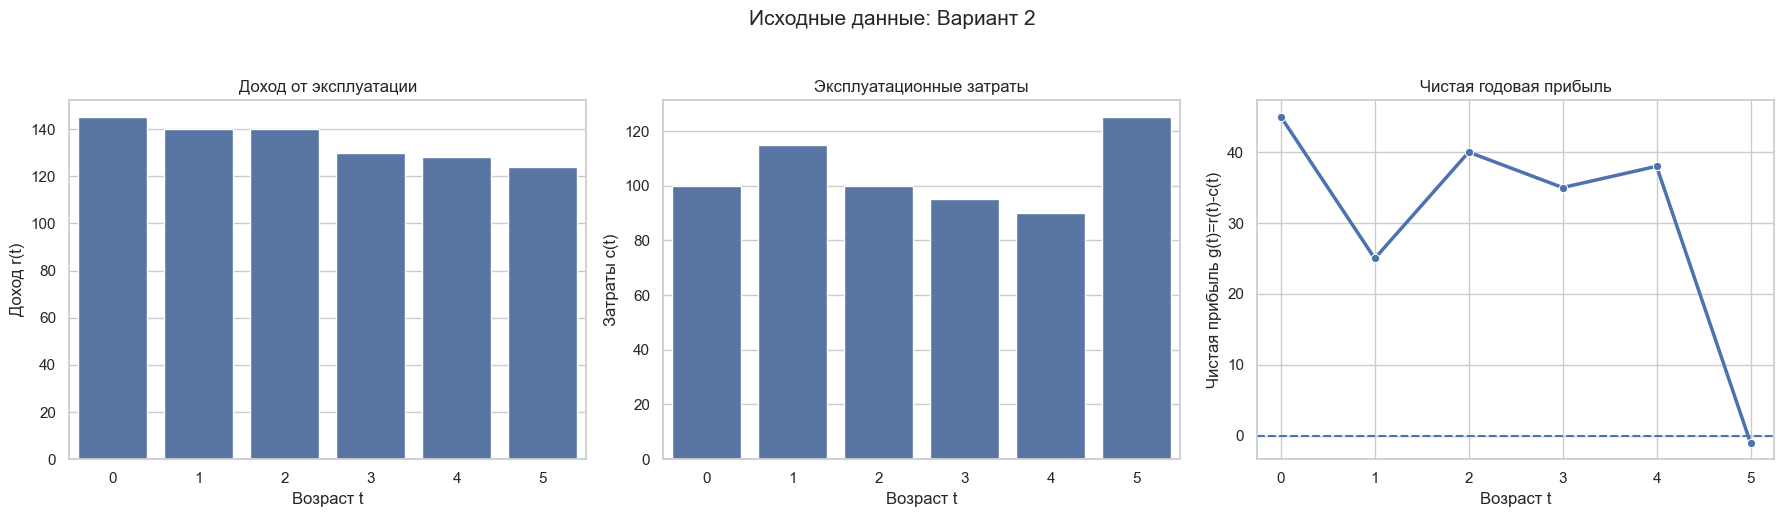

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x="Возраст t", y="Доход r(t)", ax=axes[0])
axes[0].set_title("Доход от эксплуатации")

sns.barplot(data=df, x="Возраст t", y="Затраты c(t)", ax=axes[1])
axes[1].set_title("Эксплуатационные затраты")

sns.lineplot(data=df, x="Возраст t", y="Чистая прибыль g(t)=r(t)-c(t)", marker="o", linewidth=2.5, ax=axes[2])
axes[2].set_title("Чистая годовая прибыль")
axes[2].axhline(0, linestyle="--")

plt.suptitle(f"Исходные данные: {variant['name']}", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()


In [20]:

def solve_equipment_replacement(variant , n_years: int = 5):
    ages = variant['ages']
    g = np.array(variant['revenue']) - np.array(variant['cost'])
    p = np.array(variant['replace'])
    max_age = max(ages)

    value = np.zeros((n_years + 1, max_age + 1), dtype=float)
    policy = np.empty((n_years + 1, max_age + 1), dtype=object)
    keep_gain = np.zeros((n_years + 1, max_age + 1), dtype=float)
    repl_gain = np.zeros((n_years + 1, max_age + 1), dtype=float)

    for k in range(1, n_years + 1):
        for t in ages:
            keep_next_age = min(t + 1, max_age)
            keep_val = g[t] + value[k - 1, keep_next_age]
            repl_val = g[0] - p[t] + value[k - 1, 1]

            keep_gain[k, t] = keep_val
            repl_gain[k, t] = repl_val

            if keep_val >= repl_val:
                value[k, t] = keep_val
                policy[k, t] = "Сохранить"
            else:
                value[k, t] = repl_val
                policy[k, t] = "Заменить"

    return value, policy, keep_gain, repl_gain

value, policy, keep_gain, repl_gain = solve_equipment_replacement(variant, N_YEARS)

value_df = pd.DataFrame(
    value,
    index=[f"k={k}" for k in range(N_YEARS + 1)],
    columns=[f"t={t}" for t in variant['ages']]
)
value_df


,t=0,t=1,t=2,t=3,t=4,t=5
k=0,0.0,0.0,0.0,0.0,0.0,0.0
k=1,45.0,25.0,40.0,35.0,38.0,-1.0
k=2,70.0,65.0,75.0,73.0,37.0,10.0
k=3,110.0,100.0,113.0,72.0,59.0,50.0
k=4,145.0,138.0,112.0,94.0,94.0,85.0
k=5,183.0,143.0,138.0,132.0,132.0,123.0


In [21]:
policy_df = pd.DataFrame(
    policy[1:, :],
    index=[f"{k} лет(года) до конца горизонта" for k in range(1, N_YEARS + 1)],
    columns=[f"Возраст {t}" for t in variant['ages']]
)
policy_df


,Возраст 0,Возраст 1,Возраст 2,Возраст 3,Возраст 4,Возраст 5
1 лет(года) до конца горизонта,Сохранить,Сохранить,Сохранить,Сохранить,Сохранить,Сохранить
2 лет(года) до конца горизонта,Сохранить,Сохранить,Сохранить,Сохранить,Сохранить,Заменить
3 лет(года) до конца горизонта,Сохранить,Сохранить,Сохранить,Сохранить,Заменить,Заменить
4 лет(года) до конца горизонта,Сохранить,Сохранить,Сохранить,Сохранить,Заменить,Заменить
5 лет(года) до конца горизонта,Сохранить,Заменить,Заменить,Заменить,Заменить,Заменить


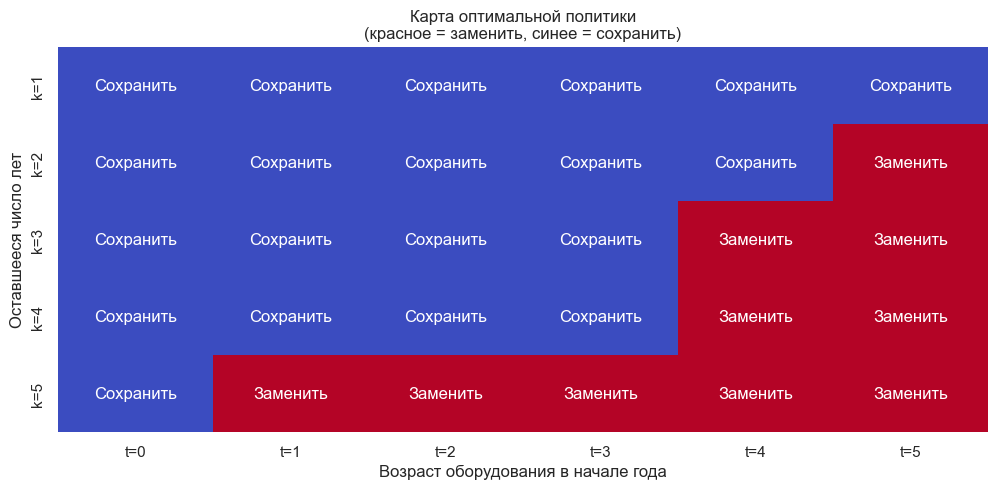

In [23]:

policy_num = np.where(policy[1:, :] == "Заменить", 1, 0)

plt.figure(figsize=(12, 5))
sns.heatmap(
    policy_num,
    annot=policy[1:, :],
    fmt="",
    cmap="coolwarm",
    cbar=False,
    xticklabels=[f"t={t}" for t in variant['ages']],
    yticklabels=[f"k={k}" for k in range(1, N_YEARS + 1)]
)
plt.title("Карта оптимальной политики\n(красное = заменить, синее = сохранить)")
plt.xlabel("Возраст оборудования в начале года")
plt.ylabel("Оставшееся число лет")
plt.show()


In [25]:
def reconstruct_plan(variant , value, policy, n_years: int, initial_age: int):
    g = np.array(variant['revenue']) - np.array(variant['cost'])
    p = np.array(variant['replace'])
    max_age = max(variant['ages'])

    rows = []
    current_age = initial_age

    for year in range(1, n_years + 1):
        k = n_years - year + 1
        decision = policy[k, current_age]

        if decision == "Сохранить":
            immediate_profit = g[current_age]
            next_age = min(current_age + 1, max_age)
        else:
            immediate_profit = g[0] - p[current_age]
            next_age = 1

        rows.append({
            "Год": year,
            "Возраст в начале года": current_age,
            "Решение": decision,
            "Прибыль за год": immediate_profit,
            "Возраст к началу следующего года": next_age,
            "Остаточная оптимальная ценность": value[k, current_age],
        })

        current_age = next_age

    return pd.DataFrame(rows)

initial_age = 3 
plan_df = reconstruct_plan(variant, value, policy, N_YEARS, initial_age)
plan_df


,Год,Возраст в начале года,Решение,Прибыль за год,Возраст к началу следующего года,Остаточная оптимальная ценность
0,1,3,Заменить,-6,1,132.0
1,2,1,Сохранить,25,2,138.0
2,3,2,Сохранить,40,3,113.0
3,4,3,Сохранить,35,4,73.0
4,5,4,Сохранить,38,5,38.0


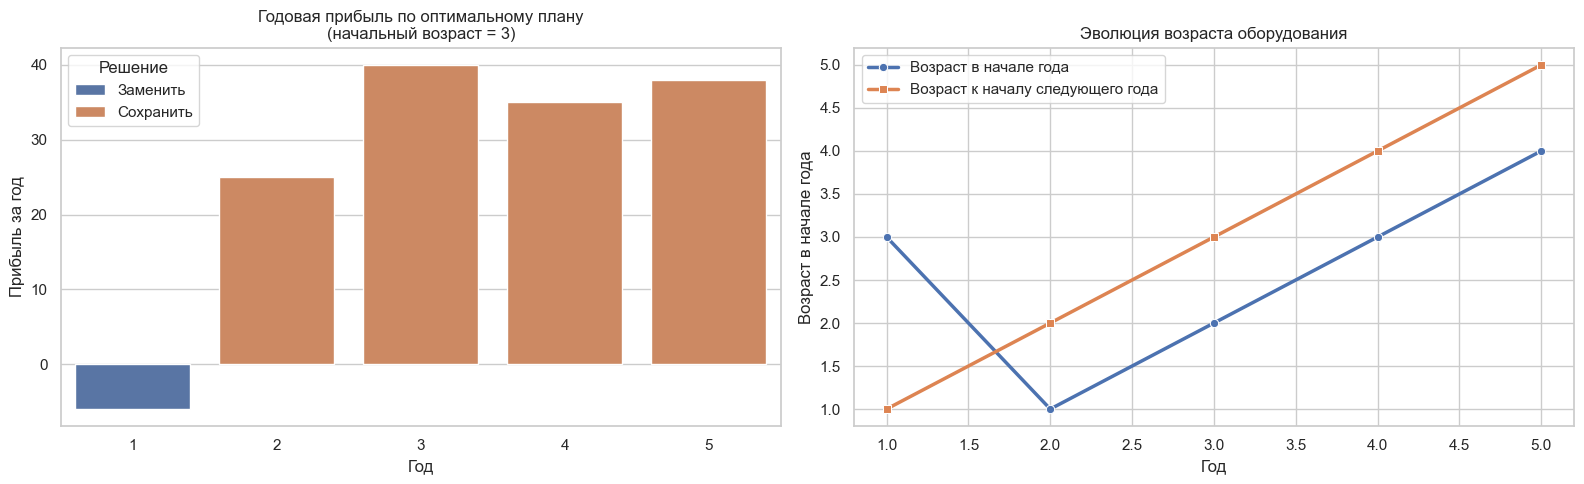

Суммарная прибыль за 5 лет при начальном возрасте 3: 132.00 д.е.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=plan_df, x="Год", y="Прибыль за год", hue="Решение", ax=axes[0])
axes[0].set_title(f"Годовая прибыль по оптимальному плану\n(начальный возраст = {initial_age})")

sns.lineplot(data=plan_df, x="Год", y="Возраст в начале года", marker="o", linewidth=2.5, ax=axes[1], label="Возраст в начале года")
sns.lineplot(data=plan_df, x="Год", y="Возраст к началу следующего года", marker="s", linewidth=2.5, ax=axes[1], label="Возраст к началу следующего года")
axes[1].set_title("Эволюция возраста оборудования")

plt.tight_layout()
plt.show()

total_profit = plan_df["Прибыль за год"].sum()
print(f"Суммарная прибыль за {N_YEARS} лет при начальном возрасте {initial_age}: {total_profit:.2f} д.е.")


In [28]:

summary_rows = []
for t0 in variant['ages']:
    temp_plan = reconstruct_plan(variant, value, policy, N_YEARS, t0)
    summary_rows.append({
        "Начальный возраст": t0,
        "Оптимальная суммарная прибыль": temp_plan["Прибыль за год"].sum(),
        "Первое решение": temp_plan.iloc[0]["Решение"],
        "Число замен за горизонт": (temp_plan["Решение"] == "Заменить").sum()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Начальный возраст,Оптимальная суммарная прибыль,Первое решение,Число замен за горизонт
0,0,183,Сохранить,0
1,1,143,Заменить,1
2,2,138,Заменить,1
3,3,132,Заменить,1
4,4,132,Заменить,1
5,5,123,Заменить,1


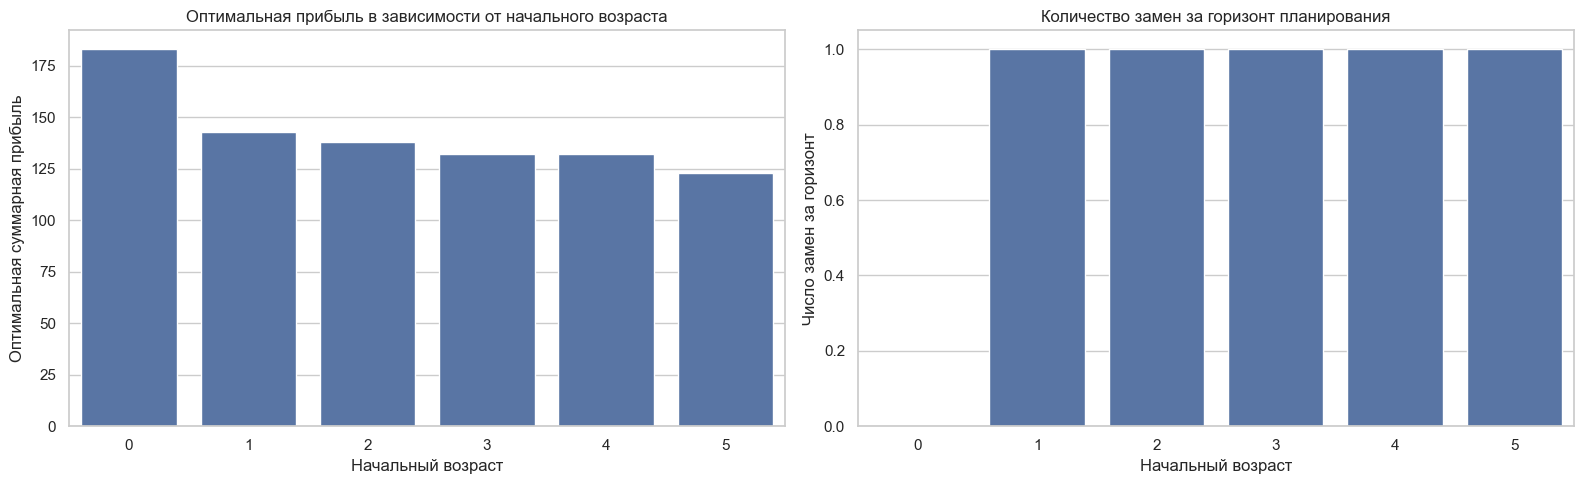

In [29]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=summary_df, x="Начальный возраст", y="Оптимальная суммарная прибыль", ax=axes[0])
axes[0].set_title("Оптимальная прибыль в зависимости от начального возраста")

sns.barplot(data=summary_df, x="Начальный возраст", y="Число замен за горизонт", ax=axes[1])
axes[1].set_title("Количество замен за горизонт планирования")

plt.tight_layout()
plt.show()


In [30]:
compare_df = pd.DataFrame({
    "Возраст t": variant['ages'],
    "Выгода сохранить": keep_gain[N_YEARS, :],
    "Выгода заменить": repl_gain[N_YEARS, :],
})
compare_df["Преимущество замены над сохранением"] = compare_df["Выгода заменить"] - compare_df["Выгода сохранить"]
compare_df


,Возраст t,Выгода сохранить,Выгода заменить,Преимущество замены над сохранением
0,0,183.0,183.0,0.0
1,1,137.0,143.0,6.0
2,2,134.0,138.0,4.0
3,3,129.0,132.0,3.0
4,4,123.0,132.0,9.0
5,5,84.0,123.0,39.0


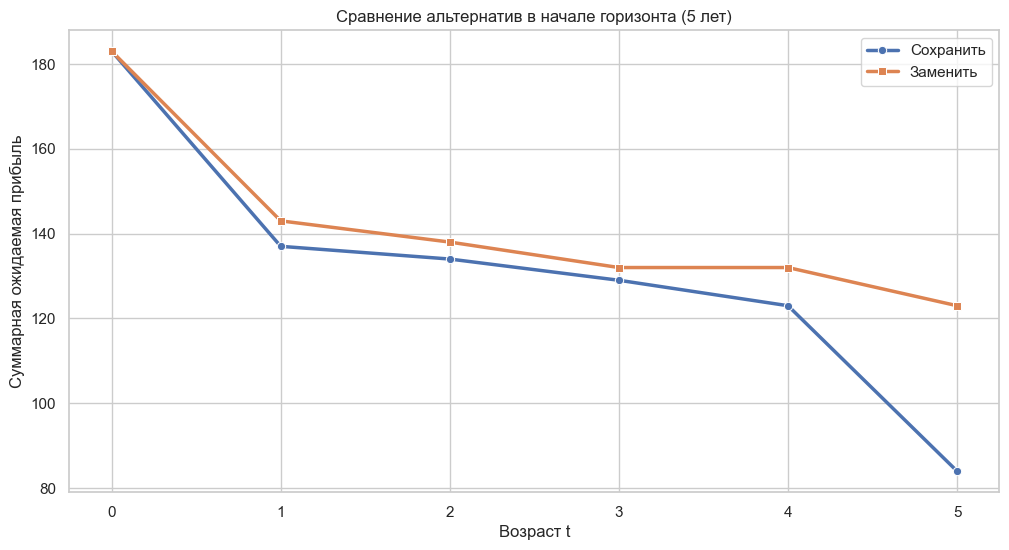

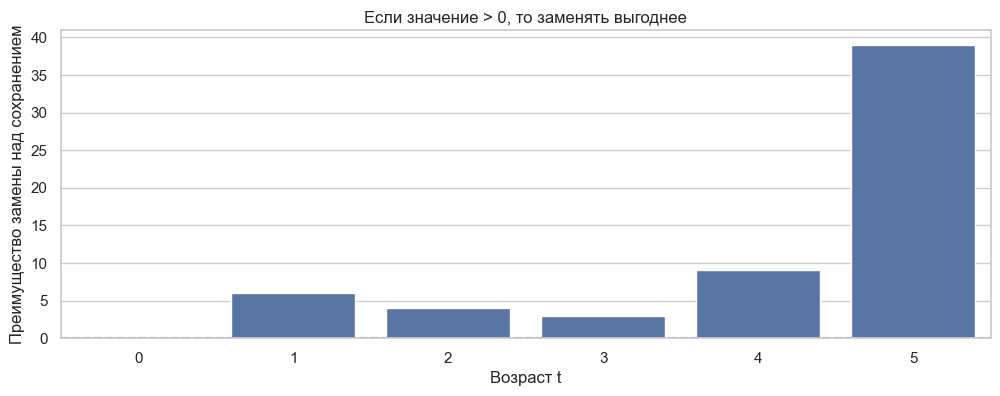

In [31]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=compare_df, x="Возраст t", y="Выгода сохранить", marker="o", linewidth=2.5, label="Сохранить")
sns.lineplot(data=compare_df, x="Возраст t", y="Выгода заменить", marker="s", linewidth=2.5, label="Заменить")
plt.title(f"Сравнение альтернатив в начале горизонта ({N_YEARS} лет)")
plt.ylabel("Суммарная ожидаемая прибыль")
plt.show()

plt.figure(figsize=(12, 4))
sns.barplot(data=compare_df, x="Возраст t", y="Преимущество замены над сохранением")
plt.axhline(0, linestyle="--")
plt.title("Если значение > 0, то заменять выгоднее")
plt.show()


In [32]:

def solve_with_discount(variant , n_years: int = 5, beta: float = 1.0):
    ages = variant['ages']
    g = np.array(variant['revenue']) - np.array(variant['cost'])
    p = np.array(variant['replace'])
    max_age = max(ages)

    value = np.zeros((n_years + 1, max_age + 1), dtype=float)
    policy = np.empty((n_years + 1, max_age + 1), dtype=object)

    for k in range(1, n_years + 1):
        for t in ages:
            keep_val = g[t] + beta * value[k - 1, min(t + 1, max_age)]
            repl_val = g[0] - p[t] + beta * value[k - 1, 1]
            if keep_val >= repl_val:
                value[k, t] = keep_val
                policy[k, t] = "Сохранить"
            else:
                value[k, t] = repl_val
                policy[k, t] = "Заменить"
    return value, policy

discount_rows = []
for beta in [1.0, 0.97, 0.94, 0.90, 0.85]:
    val_b, pol_b = solve_with_discount(variant, N_YEARS, beta=beta)
    plan_b = reconstruct_plan(variant, val_b, pol_b, N_YEARS, initial_age=3)
    discount_rows.append({
        "beta": beta,
        "Итоговая прибыль": plan_b["Прибыль за год"].sum(),
        "Первое решение": plan_b.iloc[0]["Решение"],
        "Число замен": (plan_b["Решение"] == "Заменить").sum()
    })

discount_df = pd.DataFrame(discount_rows)
discount_df


,beta,Итоговая прибыль,Первое решение,Число замен
0,1.00,132,Заменить,1
1,0.97,132,Заменить,1
2,0.94,129,Сохранить,1
3,0.90,129,Сохранить,1
4,0.85,123,Сохранить,1


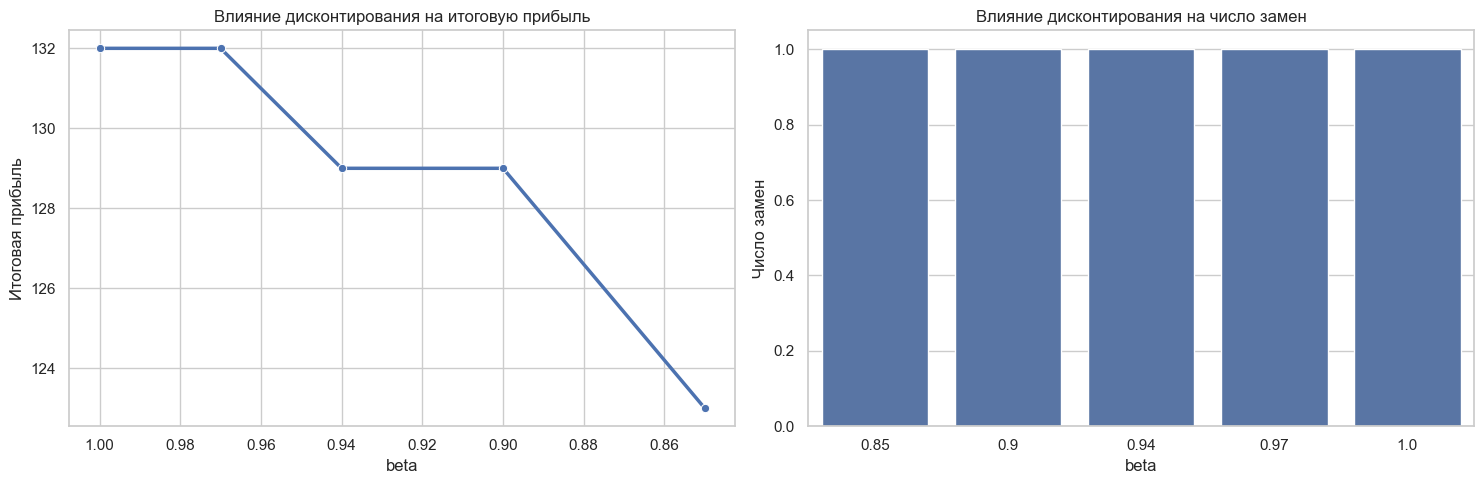

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=discount_df, x="beta", y="Итоговая прибыль", marker="o", linewidth=2.5, ax=axes[0])
axes[0].set_title("Влияние дисконтирования на итоговую прибыль")
axes[0].invert_xaxis()

sns.barplot(data=discount_df, x="beta", y="Число замен", ax=axes[1])
axes[1].set_title("Влияние дисконтирования на число замен")

plt.tight_layout()
plt.show()
